# Hypothesen – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/hypothesen)

Eine **Hypothese** ist eine Annahme, die weder bestätigt noch widerlegt ist.
Im Forschungsprozess wird sie zu Beginn aufgestellt und dann mit Daten geprüft.

| Begriff | Bedeutung |
|---|---|
| **Hypothese** | Annahme über die Grundgesamtheit, die getestet werden soll |
| **Nullhypothese H₀** | Kein Effekt / kein Unterschied vorhanden |
| **Alternativhypothese H₁** | Effekt / Unterschied ist vorhanden |
| **Hypothesentest** | Statistisches Verfahren zur Prüfung der Hypothese |
| **Signifikanzniveau α** | Maximale Irrtumswahrscheinlichkeit (oft 5 %) |

**Beispiel (numiqo):**
- Forschungsfrage: *Verdienen Männer in Österreich im gleichen Beruf mehr als Frauen?*
- H₀: Das Gehalt von Männern und Frauen **unterscheidet sich nicht**
- H₁: Das Gehalt von Männern und Frauen **unterscheidet sich**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Nullhypothese H₀ und Alternativhypothese H₁

Es gibt immer **zwei gegensätzliche Hypothesen**:

### Nullhypothese H₀
- Geht davon aus, dass **kein Unterschied / kein Effekt** vorliegt
- Wird im Hypothesentest direkt geprüft
- Ziel: H₀ verwerfen oder beibehalten

### Alternativhypothese H₁
- Geht davon aus, dass **ein Unterschied / ein Effekt** vorliegt
- Entspricht in der Regel der eigentlichen Forschungshypothese
- Kann **nie direkt bewiesen** werden – nur indirekt durch Ablehnen von H₀

> **Wichtig:** Im Hypothesentest wird immer nur H₀ geprüft.
> Wenn H₀ abgelehnt wird, gilt H₁ als vorläufig bestätigt.

### Beispiele

| Fragestellung | H₀ | H₁ |
|---|---|---|
| Gehaltsunterschied Geschlecht | Kein Unterschied | Unterschied vorhanden |
| Herzinfarktrisiko Raucher | Kein Unterschied | Raucher haben höheres Risiko |
| Mathe-Note und Gehalt | Kein Zusammenhang | Zusammenhang vorhanden |

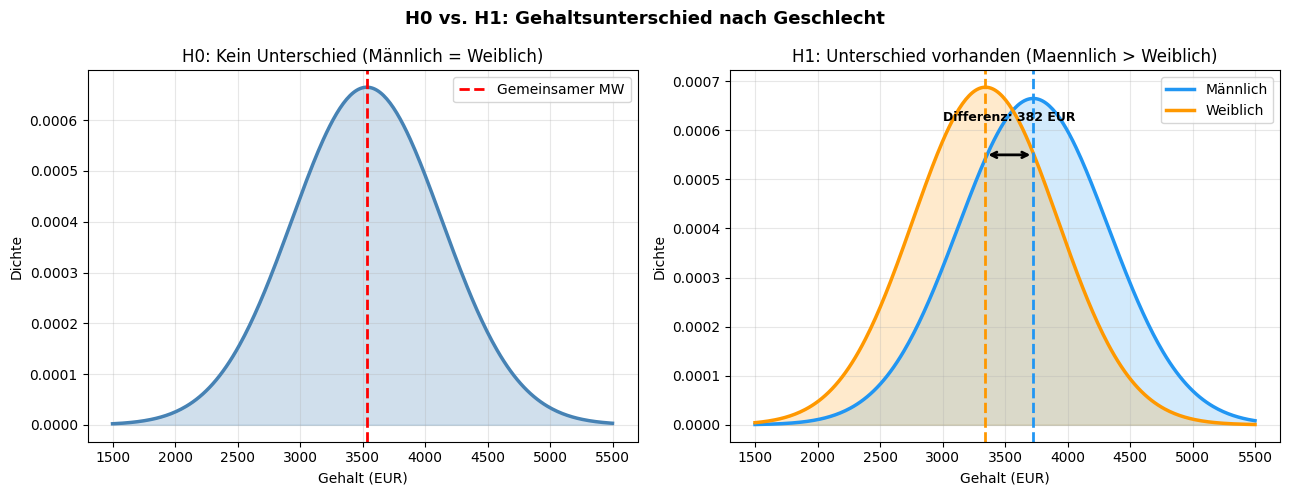

Mittelwert männlich: 3725.7 EUR
Mittelwert weiblich:  3343.41 EUR
Differenz:            382.29 EUR


In [8]:
# H0 vs H1 visualisieren – Gehaltsbeispiel
np.random.seed(42)
n = 80
gehalt_maennlich = np.random.normal(3800, 600, n)
gehalt_weiblich  = np.random.normal(3350, 580, n)

mw_m = gehalt_maennlich.mean()
mw_w = gehalt_weiblich.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H0 vs. H1: Gehaltsunterschied nach Geschlecht", fontsize=13, fontweight="bold")

# H0: kein Unterschied (beide Verteilungen uebereinander gelegt)
x = np.linspace(1500, 5500, 300)
y_mw = stats.norm.pdf(x, (mw_m + mw_w)/2, 600)
axes[0].plot(x, y_mw, color="steelblue", linewidth=2.5)
axes[0].fill_between(x, y_mw, alpha=0.25, color="steelblue")
axes[0].axvline((mw_m + mw_w)/2, color="red", linestyle="--",
                linewidth=2, label="Gemeinsamer MW")
axes[0].set_title("H0: Kein Unterschied (Männlich = Weiblich)")
axes[0].set_xlabel("Gehalt (EUR)")
axes[0].set_ylabel("Dichte")
axes[0].legend()
axes[0].grid(alpha=0.3)

# H1: Unterschied sichtbar
y_m = stats.norm.pdf(x, mw_m, 600)
y_w = stats.norm.pdf(x, mw_w, 580)
axes[1].plot(x, y_m, color="#2196F3", linewidth=2.5, label="Männlich")
axes[1].plot(x, y_w, color="#FF9800", linewidth=2.5, label="Weiblich")
axes[1].fill_between(x, y_m, alpha=0.2, color="#2196F3")
axes[1].fill_between(x, y_w, alpha=0.2, color="#FF9800")
axes[1].axvline(mw_m, color="#2196F3", linestyle="--", linewidth=2)
axes[1].axvline(mw_w, color="#FF9800", linestyle="--", linewidth=2)
axes[1].annotate("", xy=(mw_w, 0.00055), xytext=(mw_m, 0.00055),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=2))
axes[1].text((mw_m+mw_w)/2, 0.00062,
             "Differenz: " + str(round(mw_m - mw_w)) + " EUR",
             ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("H1: Unterschied vorhanden (Maennlich > Weiblich)")
axes[1].set_xlabel("Gehalt (EUR)")
axes[1].set_ylabel("Dichte")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Mittelwert männlich: " + str(round(mw_m, 2)) + " EUR")
print("Mittelwert weiblich:  " + str(round(mw_w, 2)) + " EUR")
print("Differenz:            " + str(round(mw_m - mw_w, 2)) + " EUR")

## 2. Arten von Hypothesen

### 2.1 Unterschieds- vs. Zusammenhangshypothesen

| | Unterschiedshypothese | Zusammenhangshypothese |
|---|---|---|
| **Frage** | Unterscheiden sich Gruppen? | Besteht ein Zusammenhang zwischen Variablen? |
| **Variablen** | 1 kategorisch + 1 metrisch | 2 metrische (mind. ordinal) |
| **Typische Form** | „Gruppe A hat höhere Werte als Gruppe B" | „Je mehr X, desto höher Y" |
| **Passende Tests** | t-Test, ANOVA, Mann-Whitney | Korrelation, Regression |

**Beispiele Unterschiedshypothesen:**
- Männer verdienen mehr als Frauen
- Raucher haben ein höheres Herzinfarktrisiko als Nichtraucher
- Deutschland, Österreich und Frankreich unterscheiden sich in den Arbeitsstunden/Woche

**Beispiele Zusammenhangshypothesen:**
- Je größer eine Person ist, desto schwerer ist sie
- Je mehr PS ein Auto hat, desto höher ist der Verbrauch
- Je besser die Mathe-Note, desto höher das zukünftige Gehalt

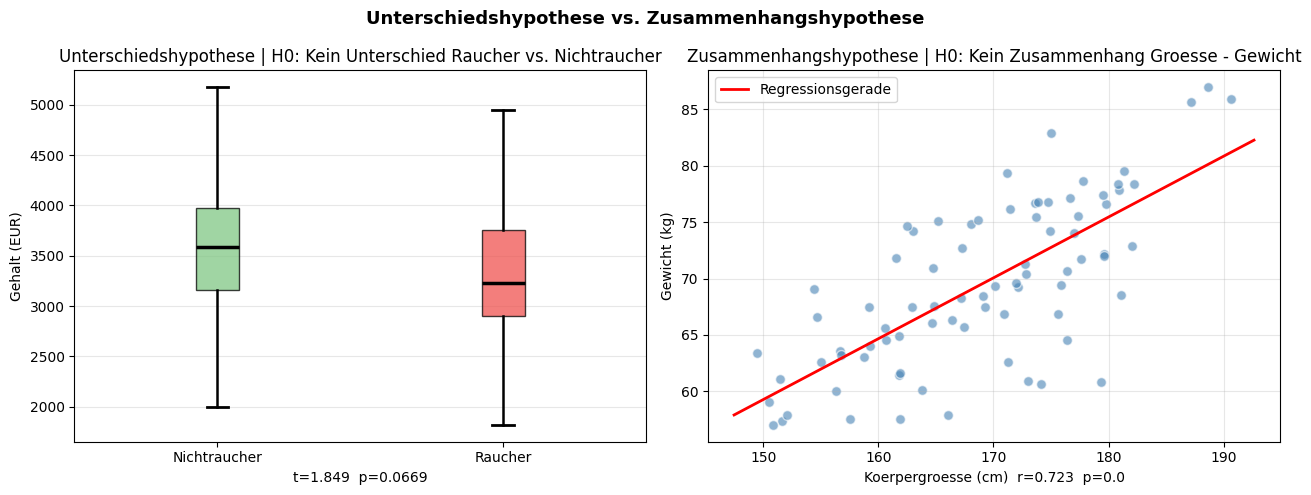

In [9]:
# Unterschiedshypothese vs. Zusammenhangshypothese visualisieren
np.random.seed(7)

# Unterschiedshypothese: Gehalt nach Raucherstatus
nichtraucher = np.random.normal(3600, 700, 60)
raucher      = np.random.normal(3250, 750, 60)

# Zusammenhangshypothese: Körpergroesse und Gewicht
groesse = np.random.normal(170, 10, 80)
gewicht = 0.5 * groesse + np.random.normal(0, 6, 80) - 15

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Unterschiedshypothese vs. Zusammenhangshypothese", fontsize=13, fontweight="bold")

# Links: Unterschiedshypothese → Boxplot
bp = axes[0].boxplot([nichtraucher, raucher], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.8),
                     capprops=dict(linewidth=2))
farben_bp = ["#81C784", "#EF5350"]
for patch, farbe in zip(bp["boxes"], farben_bp):
    patch.set_facecolor(farbe)
    patch.set_alpha(0.75)
axes[0].set_title("Unterschiedshypothese | H0: Kein Unterschied Raucher vs. Nichtraucher")
axes[0].set_ylabel("Gehalt (EUR)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Nichtraucher", "Raucher"])
axes[0].grid(axis="y", alpha=0.3)
t_stat, p_val = stats.ttest_ind(nichtraucher, raucher)
axes[0].set_xlabel("t=" + str(round(t_stat, 3)) + "  p=" + str(round(p_val, 4)))

# Rechts: Zusammenhangshypothese → Streudiagramm
r, p_r = stats.pearsonr(groesse, gewicht)
m, b   = np.polyfit(groesse, gewicht, 1)
x_l    = np.linspace(groesse.min()-2, groesse.max()+2, 100)
axes[1].scatter(groesse, gewicht, color="steelblue", alpha=0.6,
                edgecolors="white", s=50)
axes[1].plot(x_l, m*x_l + b, color="red", linewidth=2,
             label="Regressionsgerade")
axes[1].set_title("Zusammenhangshypothese | H0: Kein Zusammenhang Groesse - Gewicht")
axes[1].set_xlabel("Koerpergroesse (cm)")
axes[1].set_ylabel("Gewicht (kg)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Koerpergroesse (cm)  r=" + str(round(r, 3)) + "  p=" + str(round(p_r, 4)))

plt.tight_layout()
plt.show()

## 3. Gerichtete und ungerichtete Hypothesen

### Ungerichtete Hypothesen (zweiseitig)
Prüfen, ob ein **Unterschied / Zusammenhang** besteht – ohne Richtung anzugeben.
- „Es gibt einen Unterschied zwischen dem Gehalt von Männern und Frauen"
- „Es gibt einen Zusammenhang zwischen Körpergröße und Gewicht"

### Gerichtete Hypothesen (einseitig)
Geben zusätzlich die **Richtung** des Unterschieds / Zusammenhangs an.
- „Männer verdienen **mehr** als Frauen"
- „**Je größer** eine Person, desto **schwerer** ist sie"

### p-Wert bei gerichteten Hypothesen

$$p_{\text{einseitig}} = \frac{p_{\text{zweiseitig}}}{2}$$

> Wichtig: Nur wenn der Mittelwertsunterschied **in die erwartete Richtung** geht,
> darf durch 2 geteilt werden!

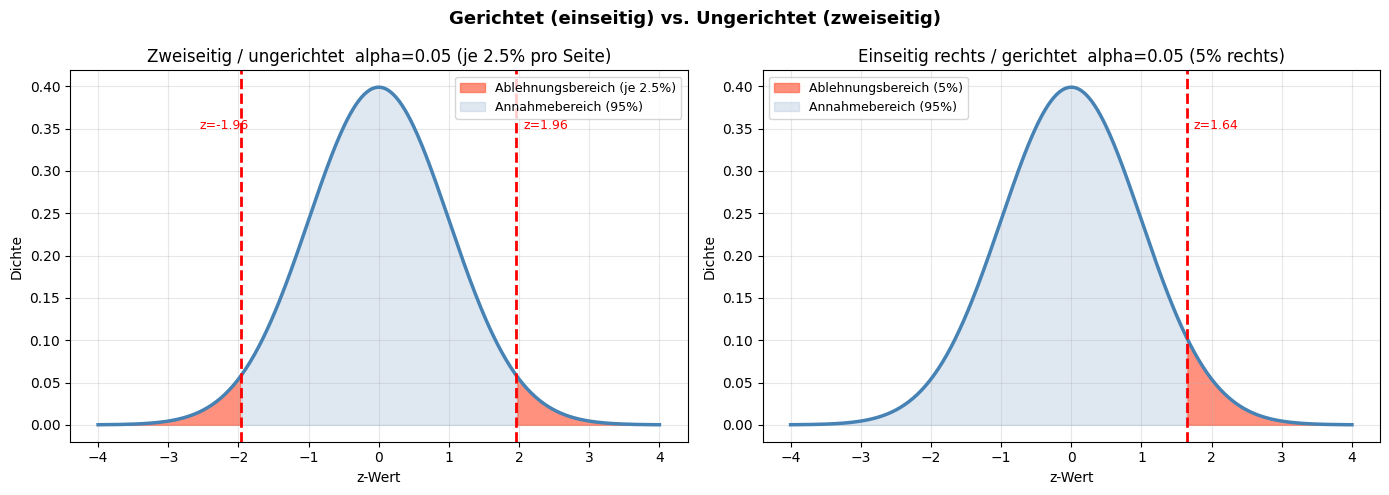

Kritischer z-Wert (zweiseitig, alpha=0.05):  +/-1.96
Kritischer z-Wert (einseitig,  alpha=0.05):  1.645

p-Wert-Umrechnung (Beispiel):
  p (zweiseitig) = 0.04
  p (einseitig)  = 0.04 / 2 = 0.02


In [4]:
# Einseitiger vs. zweiseitiger Test – Visualisierung
from scipy.stats import norm as norm_dist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gerichtet (einseitig) vs. Ungerichtet (zweiseitig)",
             fontsize=13, fontweight="bold")

x = np.linspace(-4, 4, 400)
y = norm_dist.pdf(x, 0, 1)
alpha = 0.05

# Zweiseitig: alpha auf beide Seiten aufgeteilt (je 2.5%)
z_krit_2 = norm_dist.ppf(1 - alpha/2)  # 1.96
axes[0].plot(x, y, color="steelblue", linewidth=2.5)
mask_r = x >= z_krit_2
mask_l = x <= -z_krit_2
axes[0].fill_between(x[mask_r], y[mask_r], color="tomato", alpha=0.7,
                     label="Ablehnungsbereich (je 2.5%)")
axes[0].fill_between(x[mask_l], y[mask_l], color="tomato", alpha=0.7)
axes[0].fill_between(x[~mask_r & ~mask_l], y[~mask_r & ~mask_l],
                     color="lightsteelblue", alpha=0.4,
                     label="Annahmebereich (95%)")
axes[0].axvline( z_krit_2, color="red", linestyle="--", linewidth=2)
axes[0].axvline(-z_krit_2, color="red", linestyle="--", linewidth=2)
axes[0].text( z_krit_2 + 0.1, 0.35, "z=" + str(round(z_krit_2, 2)),
              color="red", fontsize=9)
axes[0].text(-z_krit_2 - 0.6, 0.35, "z=" + str(round(-z_krit_2, 2)),
              color="red", fontsize=9)
axes[0].set_title("Zweiseitig / ungerichtet  alpha=" + str(alpha) + " (je 2.5% pro Seite)")
axes[0].set_xlabel("z-Wert")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Einseitig rechts: alpha komplett auf eine Seite (5%)
z_krit_1 = norm_dist.ppf(1 - alpha)  # 1.645
axes[1].plot(x, y, color="steelblue", linewidth=2.5)
mask_r1 = x >= z_krit_1
axes[1].fill_between(x[mask_r1], y[mask_r1], color="tomato", alpha=0.7,
                     label="Ablehnungsbereich (5%)")
axes[1].fill_between(x[~mask_r1], y[~mask_r1],
                     color="lightsteelblue", alpha=0.4,
                     label="Annahmebereich (95%)")
axes[1].axvline(z_krit_1, color="red", linestyle="--", linewidth=2)
axes[1].text(z_krit_1 + 0.1, 0.35, "z=" + str(round(z_krit_1, 2)),
             color="red", fontsize=9)
axes[1].set_title("Einseitig rechts / gerichtet  alpha=" + str(alpha) + " (5% rechts)")
axes[1].set_xlabel("z-Wert")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Kritischer z-Wert (zweiseitig, alpha=0.05):  +/-" + str(round(z_krit_2, 3)))
print("Kritischer z-Wert (einseitig,  alpha=0.05):  " + str(round(z_krit_1, 3)))
print()
print("p-Wert-Umrechnung (Beispiel):")
p_zwei = 0.04
p_ein  = p_zwei / 2
print("  p (zweiseitig) = " + str(p_zwei))
print("  p (einseitig)  = " + str(p_zwei) + " / 2 = " + str(p_ein))

## 4. Schritt-für-Schritt: Hypothese aufstellen und testen

Laut numiqo folgt das Testen einer Hypothese diesen Schritten:

1. **Literaturrecherche** – vorhandene Studien und Theorien sichten
2. **Hypothese formulieren** – präzise Aussage über die Grundgesamtheit
3. **Operationalisierung** – Variablen messbar machen
4. **Signifikanzniveau festlegen** – meist α = 0,05 (5 %)
5. **Hypothesenart bestimmen** – gerichtet oder ungerichtet?
6. **Skalenniveau prüfen** – nominal, ordinal oder metrisch?
7. **Passenden Hypothesentest wählen**
8. **Test berechnen und p-Wert interpretieren**

In [11]:
# Vollstaendiges Beispiel: Gehalt Männlich vs. Weiblich
# Schritte 1-8 anhand des numiqo-Beispiels

print("Schritt-für-Schritt: Hypothesentest")
print()
print("Schritt 1: Forschungsfrage")
print("  Verdienen Männer in Deutschland im gleichen Beruf mehr als Frauen?")
print()
print("Schritt 2: Hypothesen formulieren")
print("  H0: Das Gehalt von Männern und Frauen unterscheidet sich NICHT")
print("  H1: Männer verdienen MEHR als Frauen  (gerichtet, einseitig)")
print()
print("Schritt 3: Operationalisierung")
print("  Variable 1: Geschlecht (nominal: maennlich / weiblich)")
print("  Variable 2: Jahresgehalt in EUR (metrisch)")
print()
print("Schritt 4: Signifikanzniveau")
alpha = 0.05
print("  alpha = " + str(alpha) + "  (5 %)")
print()

# Daten
np.random.seed(42)
gehalt_m = pd.Series(np.random.normal(52000, 8000, 80))
gehalt_w = pd.Series(np.random.normal(48500, 7500, 80))

print("Schritt 5: Hypothesenart")
print("  Gerichtet (einseitig) – H1 sagt: Maenner > Frauen")
print()
print("Schritt 6: Skalenniveau")
print("  Geschlecht: nominal | Gehalt: metrisch -> t-Test")
print()
print("Schritt 7: Hypothesentest waehlen")
print("  Unabhaengiger t-Test (zwei unabhaengige Gruppen, metrische AV)")
print()

# t-Test berechnen
t_stat, p_two = stats.ttest_ind(gehalt_m, gehalt_w)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2   # einseitig rechts

print("Schritt 8: Test berechnen und interpretieren")
print("  n männlich: " + str(len(gehalt_m)) +
      "  MW=" + str(round(gehalt_m.mean(), 0)) + " EUR")
print("  n weiblich:  " + str(len(gehalt_w)) +
      "  MW=" + str(round(gehalt_w.mean(), 0)) + " EUR")
print("  t-Statistik:          " + str(round(t_stat, 4)))
print("  p-Wert (zweiseitig):  " + str(round(p_two, 4)))
print("  p-Wert (einseitig):   " + str(round(p_one, 4)))
print()

if p_one < alpha:
    print("  Ergebnis: p=" + str(round(p_one, 4)) +
          " < alpha=" + str(alpha))
    print("  -> H0 wird ABGELEHNT")
    print("  -> H1 ist vorlaefig bestaetigt: Männer verdienen signifikant mehr")
else:
    print("  Ergebnis: p=" + str(round(p_one, 4)) +
          " >= alpha=" + str(alpha))
    print("  -> H0 wird BEIBEHALTEN")
    print("  -> Kein signifikanter Unterschied nachweisbar")

Schritt-für-Schritt: Hypothesentest

Schritt 1: Forschungsfrage
  Verdienen Männer in Deutschland im gleichen Beruf mehr als Frauen?

Schritt 2: Hypothesen formulieren
  H0: Das Gehalt von Männern und Frauen unterscheidet sich NICHT
  H1: Männer verdienen MEHR als Frauen  (gerichtet, einseitig)

Schritt 3: Operationalisierung
  Variable 1: Geschlecht (nominal: maennlich / weiblich)
  Variable 2: Jahresgehalt in EUR (metrisch)

Schritt 4: Signifikanzniveau
  alpha = 0.05  (5 %)

Schritt 5: Hypothesenart
  Gerichtet (einseitig) – H1 sagt: Maenner > Frauen

Schritt 6: Skalenniveau
  Geschlecht: nominal | Gehalt: metrisch -> t-Test

Schritt 7: Hypothesentest waehlen
  Unabhaengiger t-Test (zwei unabhaengige Gruppen, metrische AV)

Schritt 8: Test berechnen und interpretieren
  n männlich: 80  MW=51009.0 EUR
  n weiblich:  80  MW=48415.0 EUR
  t-Statistik:          2.2536
  p-Wert (zweiseitig):  0.0256
  p-Wert (einseitig):   0.0128

  Ergebnis: p=0.0128 < alpha=0.05
  -> H0 wird ABGELEHNT


## 5. Welcher Hypothesentest passt?

Die Wahl des Hypothesentests hängt von der **Hypothesenart** und dem
**Skalenniveau** der Variablen ab:

### Unterschiedshypothesen

| Gruppen | Skalenniveau AV | Parametrisch | Nicht-parametrisch |
|---|---|---|---|
| 2 unabhängige | Metrisch | t-Test (unabh.) | Mann-Whitney-U |
| 2 abhängige | Metrisch | t-Test (abh.) | Wilcoxon |
| 3+ unabhängige | Metrisch | ANOVA | Kruskal-Wallis |
| Kategorisch | Nominal | Chi-Quadrat-Test | — |

### Zusammenhangshypothesen

| Skalenniveau | Parametrisch | Nicht-parametrisch |
|---|---|---|
| Metrisch | Pearson-Korrelation / Regression | Spearman-Korrelation |
| Ordinal | — | Spearman / Kendalls Tau |

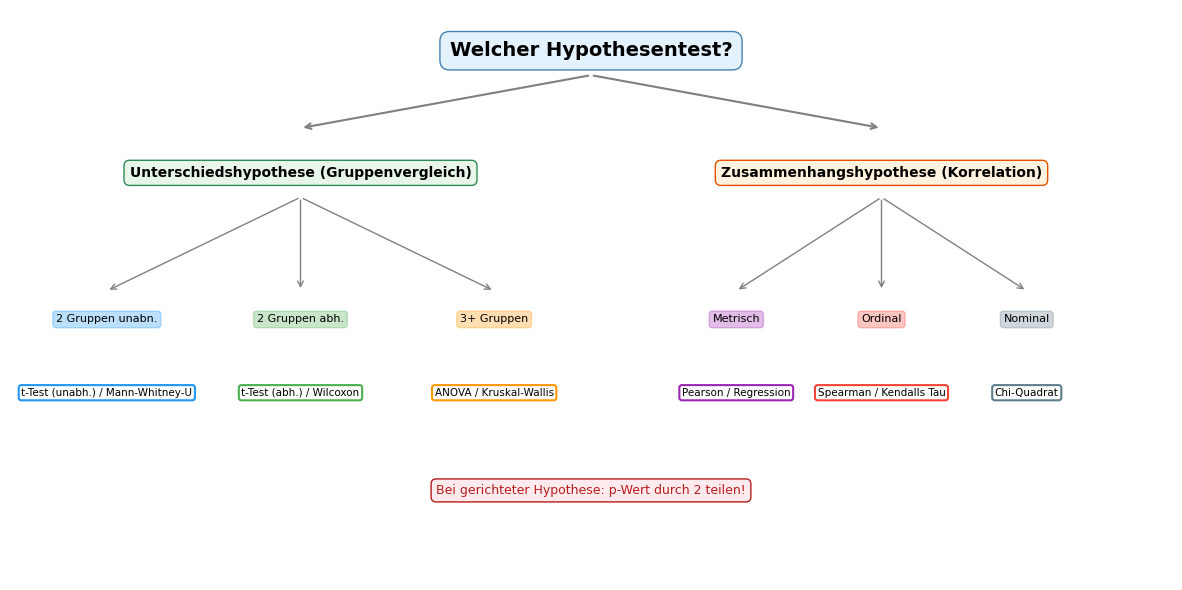

In [6]:
# Hypothesenarten und passende Tests – Visualisierung
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)

# Titel
ax.text(6, 6.5, "Welcher Hypothesentest?", ha="center", va="center",
        fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#E3F2FD", edgecolor="steelblue"))

# Hauptzweige
zweige = [
    (3,   5,   "Unterschiedshypothese (Gruppenvergleich)", "#E8F5E9", "seagreen"),
    (9,   5,   "Zusammenhangshypothese (Korrelation)", "#FFF3E0", "#E65100"),
]
for x, y, text, bg, ec in zweige:
    ax.text(x, y, text, ha="center", va="center", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=bg, edgecolor=ec))
    ax.annotate("", xy=(x, y + 0.55), xytext=(6, 6.2),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# Unterschiedshypothese – Unterzweige
unterzweige_u = [
    (1,   3.2, "2 Gruppen unabn.", "#2196F3", "t-Test (unabh.) / Mann-Whitney-U"),
    (3,   3.2, "2 Gruppen abh.", "#4CAF50", "t-Test (abh.) / Wilcoxon"),
    (5,   3.2, "3+ Gruppen", "#FF9800", "ANOVA / Kruskal-Wallis"),
]
for x, y, label, farbe, test in unterzweige_u:
    ax.text(x, y, label, ha="center", va="center", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=farbe, alpha=0.3,
                      edgecolor=farbe))
    ax.text(x, y - 0.9, test, ha="center", va="center", fontsize=7.5,
            color="black",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=farbe, linewidth=1.5))
    ax.annotate("", xy=(x, y + 0.35), xytext=(3, 4.7),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Zusammenhangshypothese – Unterzweige
unterzweige_z = [
    (7.5, 3.2, "Metrisch",  "#9C27B0", "Pearson / Regression"),
    (9,   3.2, "Ordinal",   "#F44336", "Spearman / Kendalls Tau"),
    (10.5,3.2, "Nominal",   "#607D8B", "Chi-Quadrat"),
]
for x, y, label, farbe, test in unterzweige_z:
    ax.text(x, y, label, ha="center", va="center", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=farbe, alpha=0.3,
                      edgecolor=farbe))
    ax.text(x, y - 0.9, test, ha="center", va="center", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=farbe, linewidth=1.5))
    ax.annotate("", xy=(x, y + 0.35), xytext=(9, 4.7),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Gerichtet / Ungerichtet Hinweis
ax.text(6, 1.1, "Bei gerichteter Hypothese: p-Wert durch 2 teilen!",
        ha="center", va="center", fontsize=9, color="#B71C1C",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFEBEE",
                  edgecolor="#B71C1C"))

plt.tight_layout()
plt.show()

## 6. Zusammenfassung

```
Hypothesen – Übersicht
│
├── DEFINITION
│   Annahme über die Grundgesamtheit, die noch nicht bewiesen ist
│
├── HYPOTHESENPAAR
│   ├── H0 (Nullhypothese):       Kein Effekt / kein Unterschied
│   └── H1 (Alternativhypothese): Effekt / Unterschied vorhanden
│
├── ARTEN
│   ├── UNTERSCHIEDSHYPOTHESE
│   │   Prüft ob Gruppen sich unterscheiden
│   │   Variablen: 1 kategorisch + 1 metrisch
│   │   Tests: t-Test, ANOVA, Mann-Whitney, Chi-Quadrat
│   │
│   └── ZUSAMMENHANGSHYPOTHESE
│       Prüft ob Variablen korrelieren
│       Variablen: mind. 2 ordinale/metrische Variablen
│       Tests: Pearson/Spearman Korrelation, Regression
│
├── RICHTUNG
│   ├── UNGERICHTET (zweiseitig)
│   │   "Es gibt einen Unterschied"  (keine Richtung)
│   │   p-Wert: direkt verwenden
│   │
│   └── GERICHTET (einseitig)
│       "Gruppe A hat HOEHERE Werte als Gruppe B"
│       p-Wert: p_einseitig = p_zweiseitig / 2
│               (nur wenn Richtung stimmt!)
│
└── SCHRITTE
    1. Literaturrecherche
    2. Hypothese formulieren
    3. Operationalisierung
    4. Signifikanzniveau festlegen (alpha = 0.05)
    5. Hypothesenart bestimmen (gerichtet?)
    6. Skalenniveau prüfen
    7. Passenden Test waehlen
    8. Test berechnen und p-Wert interpretieren
```

---
Quelle: [numiqo.de/tutorial/hypothesen](https://numiqo.de/tutorial/hypothesen)